In [1]:
#@markdown # Dependency collocation

# !pip3 install -U 'git+ssh://git@git.lwp.rug.nl:/team-data-science/2021/journalistic-feelings/labelstudioexport.git'
# !pip3 install -U 'git+ssh://git@git.lwp.rug.nl:/team-data-science/2021/journalistic-feelings/lexisnexis.git'
import os
import difflib
import warnings
import numpy as np
import pandas as pd
from scipy import sparse
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from multiprocessing import Pool
from sklearn.cluster import DBSCAN
from scipy.sparse import csr_matrix
from sklearn.neighbors._base import EfficiencyWarning


tqdm.pandas()

path = '/slow-data/journalisticfeelings/' #@param {"type": "string"}
os.chdir(path)

articles_filename = './data/nexis-uni-export.p3' #@param {"type": "string"}
export_filename = './data/nexis-uni-export-unique.p3' #@param {"type": "string"}

In [2]:
#@markdown # Load articles

articles = pd.read_pickle(articles_filename)

  0%|          | 0/540 [00:00<?, ?it/s]

  0%|          | 0/3958825 [00:00<?, ?it/s]

  0%|          | 0/3958825 [00:00<?, ?it/s]

  0%|          | 0/19900 [00:00<?, ?it/s]

  0%|          | 0/19900 [00:00<?, ?it/s]

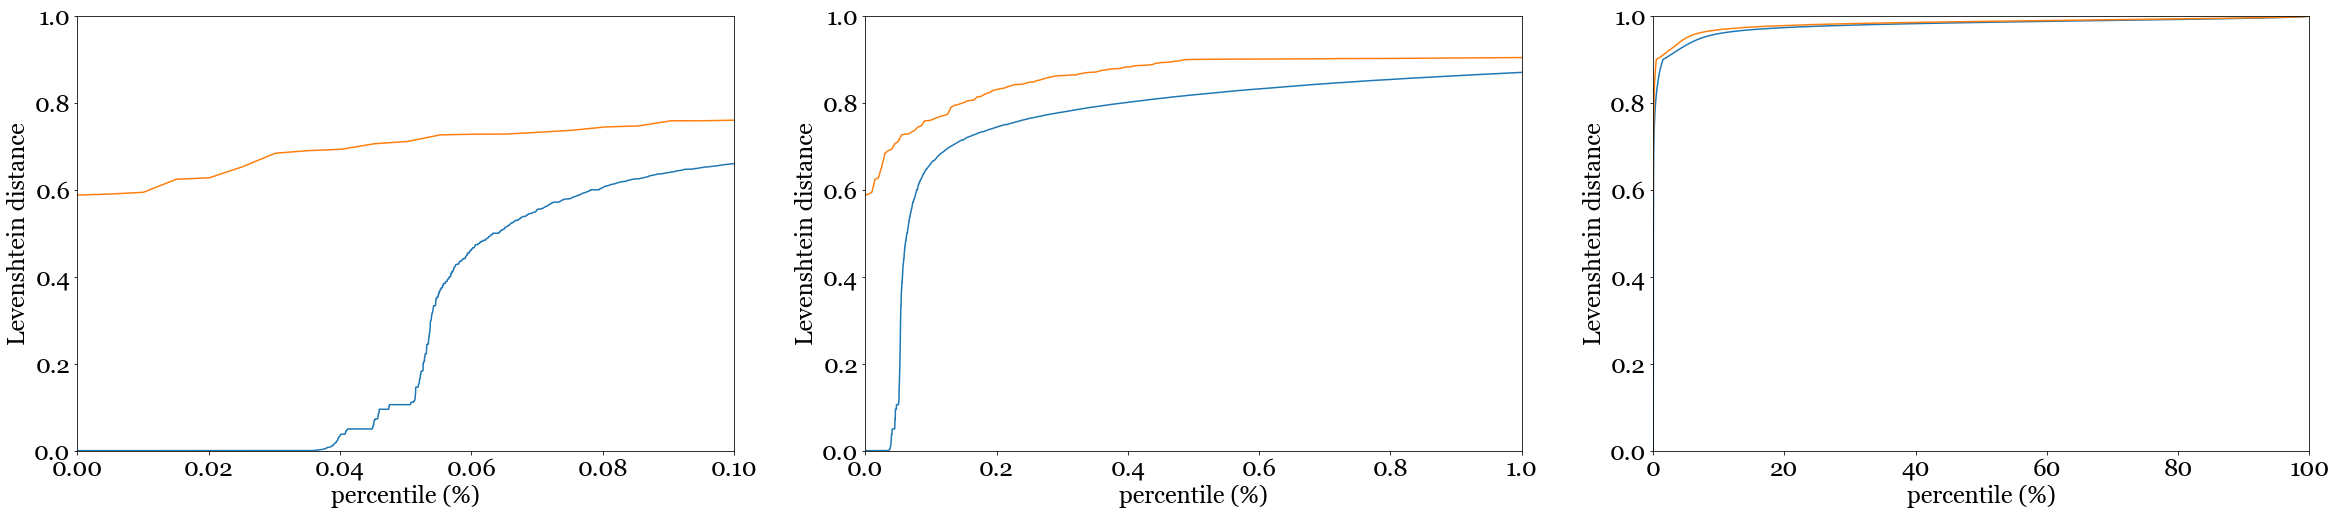

In [3]:
#@markdown # Find similar articles

#@markdown Articles within the same news paper and of the same date are
#@markdown compared pairwise w.r.t. Levenshtein distance as a percentage,
#@markdown For distances larger than 0.9 an approximation might be used for
#@markdown the purpose of efficency.

n_jobs = 40 #@param {"type": "integer"}
normality_sample_size = 200 #@param {"type": "integer"}
max_levenshtein_distance = 0.370000001 #@param {"type": "number"}

def similarity(b, a):
  # Only use the expensive variants if articles are remotely similar. The
  # pproximations are lower bounds of the distance, i.e. if quick_ratio
  # is returned, this means the actual distance might be higher, but it's
  # already at or above 0.9 anyway.

  quick_ratio = 1 - difflib.SequenceMatcher(None, a, b).real_quick_ratio()
  if quick_ratio > 0.9:
    return quick_ratio
  quick_ratio = 1 - difflib.SequenceMatcher(None, a, b).quick_ratio()
  if quick_ratio > 0.9:
    return quick_ratio
  return 1 - difflib.SequenceMatcher(None, a, b).ratio()

def cartesian(a):
  result = pd.concat(
      a.apply(lambda x: pd.DataFrame({'a': a, 'b': x})
  ).tolist(), keys=a.index, names=['a', 'b'])
  index = result.index.to_frame()
  return result[index['a'] < index['b']]

# articles in different papers or on different dates are considered different by
# choice, i.e. we only look for similarities within papers on a specific day.
if 'combinations' not in globals():
  combinations = articles['body'].str.join(' ').groupby(
      [articles['paper'], articles['date']]).progress_apply(cartesian)

if 'distances' not in globals():
  with Pool(n_jobs) as pool:
    promises = combinations.progress_apply(lambda couple: pool.apply_async(
        similarity, tuple(couple.values)), axis=1)
    distances = promises.progress_apply(lambda x: x.get())

if 'random_distances' not in globals():
  with Pool(n_jobs) as pool:
    promises = cartesian(
        articles.sample(normality_sample_size)['body'].str.join(' ')
    ).progress_apply(lambda couple: pool.apply_async(
        similarity, tuple(couple.values)), axis=1)
    random_distances = promises.progress_apply(lambda x: x.get())

plt.rcParams['font.size'] = 24
plt.rcParams['font.family'] = 'Georgia'

fig, axes = plt.subplots(1, 3, figsize=(40, 8))
sorted_distances = sorted(distances)
sorted_random_distances = sorted(random_distances)
for ax, xmax in zip(axes, [.1, 1, 100]):
  ax.plot(np.linspace(0,100, len(distances)), sorted_distances)
  ax.plot(np.linspace(0,100, len(random_distances)), sorted_random_distances)
  ax.set_ylabel('Levenshtein distance')
  ax.set_xlabel('percentile (%)')
  ax.set_xlim(0, xmax)
  ax.set_ylim(0, 1)

rows, cols, values = distances[
      distances <= max_levenshtein_distance
    ].reset_index()[['a', 'b', 0]].values.T
distance_matrix = csr_matrix(
    (np.concatenate([values, values]), (
      np.concatenate([rows, cols]),
      np.concatenate([cols, rows]))
    ), shape=(articles.index.max()+1,) * 2)

from sklearn.neighbors._base import EfficiencyWarning
with warnings.catch_warnings():
  warnings.simplefilter("ignore", EfficiencyWarning)
  clusters = DBSCAN(eps=max_levenshtein_distance, min_samples=1,
                    metric='precomputed').fit_predict(distance_matrix)

cluster_sizes = pd.Series(clusters).value_counts()
clusters_ = pd.Series(clusters).loc[articles.index]

In [4]:
#@markdown # Remove the smaller 'duplicates' that are similar

def select_from_cluster(cluster):
  if len(cluster) == 1 or len(cluster) > 3:
    return cluster
  
  # Check if found clusters are in the same newspaper on the same date.
  # assert len(cluster['zip'].str.split('-page-').str[0].unique()) == 1

  idx_max = cluster['body'].apply(lambda x: sum(len(x) for x in x if x == x)).idxmax()
  return cluster.loc[[idx_max]]

unique_articles = articles.groupby(clusters_).progress_apply(select_from_cluster)

  0%|          | 0/61551 [00:00<?, ?it/s]

In [5]:
#@markdown # Export

unique_articles.to_pickle(export_filename)